# Monthly means of surge heights from GTSM-ERA5 dataset
This notebook demonstrates the process of obtaining monthly and yearly means of surge heights for selected tide gauge station locations used in the Sea Level Monitor.
The source dataset for this notebook is the dataset of global tides and surges generated using the GTSM model forced with the ERA5 reanalysis available at Copernicus Climate Data Store at https://doi.org/10.24381/cds.a6d42d60 (variable: storm surge residual, experiment: reanalysis, temporal aggregation: hourly).

For ease of access, we are loading a local copy of this dataset in this notebook, which is identical to the dataset stored on the Copernicus Climate Data Store.

## Preparation and settings

In [2]:
import xarray as xr
import glob
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import dfm_tools as dfmt
import pandas as pd
import csv

c:\Users\aleksand\AppData\Local\miniforge3\envs\dfm_tools_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Define paths to data and output:

In [49]:
# location of hourly timeseries of surge
dir_ts = r'p:\1230882-emodnet_hrsm\GTSM-ERA5\06_model_runs\03_postprocessing\timeseries-GTSM-ERA5-hourly\surge'

In [85]:
# output directories
outdir_data = os.path.join('..','..','data','deltares','gtsm')
if not os.path.exists(outdir_data):
    os.makedirs(outdir_data)

#outdir_fig = os.path.join('.','figures_gtsm_surge')
outdir_fig = os.path.join('..','..','rapportage','slm2026','images')
if not os.path.exists(outdir_fig):
    os.makedirs(outdir_fig)

Select stations to extract from the global dataset:

In [5]:
locs = {'IJMDBTHVN': [4.556043, 52.461978],
        "VLISSGN": [3.597, 51.453], 
        "DENHDR": [4.738, 52.959], 
        "HARLNGN": [5.296, 53.21], 
        "DELFZL": [6.938, 53.32],
        "HOEKVHLD": [4.124, 51.979]} 

## Extract monthly means for selected stations from the global dataset

### Find the station IDs corresponding to the locations of interest

We load a dataset sample (one month of data) to determine the stations IDs - finding the nearest model output location to the coordinates of the tide gauges:

In [52]:
year_sel = 2025
ds_example = xr.open_dataset(os.path.join(dir_ts, f'reanalysis_surge_hourly_{year_sel}_01_v3.nc'))

In [53]:
station_ids = {}
for station_names in locs.keys():
    # find station number
    loc = locs[station_names]
    abslon = np.abs(ds_example.station_x_coordinate-loc[0])
    abslat = np.abs(ds_example.station_y_coordinate-loc[1])
    station_id = ds_example['stations'].isel(stations=np.argmin(abslon.values**2 + abslat.values**2)).values.tolist()
    station_ids[station_names] = station_id

Create a checkplot to view the locations on a map and check timeseries for one month:

>> reading coastlines: 1.08 sec


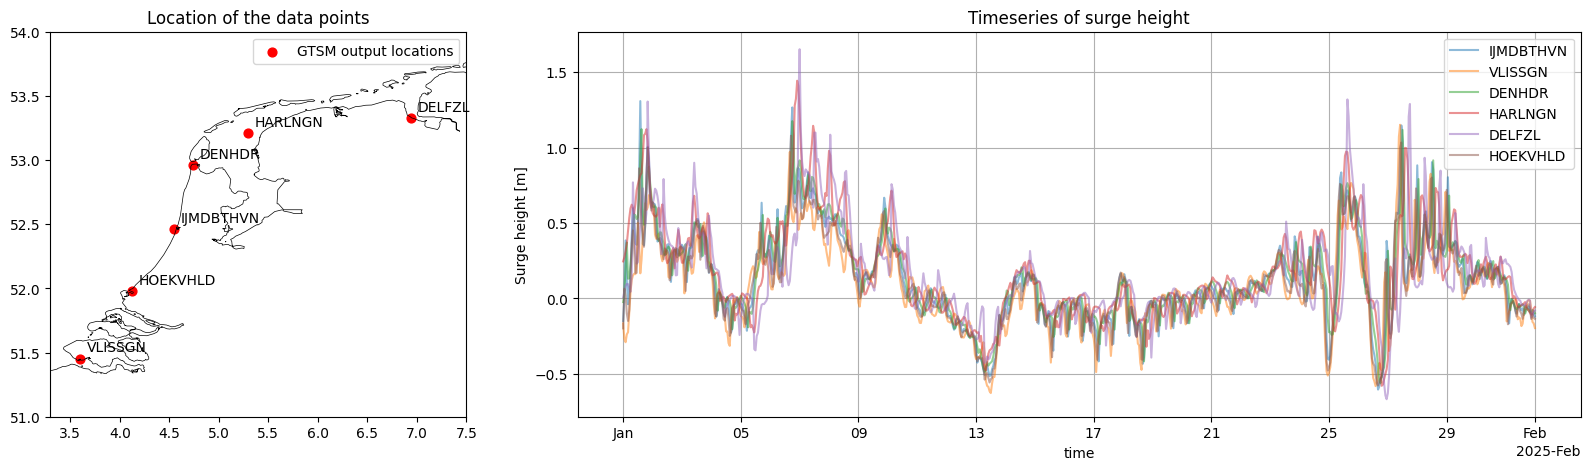

In [77]:
# Plot locations on map and check timeseries 
fig = plt.figure(figsize=(20, 5))
ax0 = plt.subplot2grid((1, 3), (0, 0))
ax1 = plt.subplot2grid((1, 3), (0, 1), colspan=2)

#    plot location on the map
ax0.set_ylim([51, 54])
ax0.set_xlim([3.3, 7.5])
bs = ax0.scatter(x=ds_example['station_x_coordinate'].where(ds_example.stations.isin(list(station_ids.values()))), 
                 y=ds_example['station_y_coordinate'].where(ds_example.stations.isin(list(station_ids.values()))), 
                 s=40, facecolors='red', label='GTSM output locations')

for station_names, station_id in station_ids.items():
    ax0.annotate(station_names, 
                 xy=(ds_example['station_x_coordinate'].sel(stations=station_id).values, 
                     ds_example['station_y_coordinate'].sel(stations=station_id).values), 
                 xytext=(5, 5), textcoords='offset points', fontsize=10)
ax0.title.set_text("Location of the data points")
dfmt.plot_coastlines(ax0)
ax0.legend()

# plot timeseries of surges
for station_names, station_id in station_ids.items():
    ds_example['surge'].sel(stations=station_id).plot(ax=ax1, alpha=0.5, label=f'{station_names}')
ax1.set_ylabel('Surge height [m]')
ax1.grid()
ax1.title.set_text('Timeseries of surge height')
ax1.legend()

### Calculate monthly means from the global dataset

Select the full time range:

In [86]:
# select year to process
yrs = range(1950,2026)

Loop over years and calculate the monthly means for selected stations, gathering the data in a dataset of monthly means:

In [ ]:
for yr in yrs:
    print(f'Processing year {yr}...')

    ts_files = glob.glob(os.path.join(dir_ts, f'reanalysis_surge_hourly_{yr}_*_v3.nc'))

    if len(ts_files) == 12:
        # open all data for that year in one dataset
        ds = xr.open_mfdataset(ts_files)
        
        # subset to stations of interest
        ds = ds.sel(stations=list(station_ids.values()), time=slice(f'{yr}-01-01', f'{yr}-12-31'))

        # resample to monthly means
        ds_monthly_mean = ds.resample(time='ME',label='right').mean()

        # create coordinate with year and month numbers
        year = ds_monthly_mean.time.dt.year
        month = ds_monthly_mean.time.dt.month
        ds_monthly_mean = ds_monthly_mean.assign_coords(year=("time", year.data), month=("time", month.data))
        
        # reshape the array to (..., "month", "year")
        ds_monthly_mean = ds_monthly_mean.set_index(time=("year", "month")).unstack("time")

        # drop the time dimension on coordinates that got added when opening the dataset
        ds_monthly_mean.load()
        ds_monthly_mean = ds_monthly_mean.set_coords(("station_y_coordinate", "station_x_coordinate"))
        
        if yr==yrs[0]:
            # create new dataset with the first year
            ds_all = ds_monthly_mean
        else:
            # merge with the previous years
            ds_all = xr.merge([ds_all, ds_monthly_mean], compat='no_conflicts', join='outer')
    else:
        print('==== Not all months are available in %s'% yr)


Processing year 1950...
Processing year 1951...
Processing year 1952...
Processing year 1953...
Processing year 1954...
Processing year 1955...
Processing year 1956...
Processing year 1957...
Processing year 1958...
Processing year 1959...
Processing year 1960...
Processing year 1961...
Processing year 1962...
Processing year 1963...
Processing year 1964...
Processing year 1965...
Processing year 1966...
Processing year 1967...
Processing year 1968...
Processing year 1969...
Processing year 1970...
Processing year 1971...
Processing year 1972...
Processing year 1973...
Processing year 1974...
Processing year 1975...
Processing year 1976...
Processing year 1977...
Processing year 1978...
Processing year 1979...
Processing year 1980...
Processing year 1981...
Processing year 1982...
Processing year 1983...
Processing year 1984...
Processing year 1985...
Processing year 1986...
Processing year 1987...
Processing year 1988...
Processing year 1989...
Processing year 1990...
Processing year 

Add station names to the dataset to enable browing by station name:

In [89]:
# assign station names with dimension stations
ds_all['station_name'] = xr.DataArray([name for name in station_ids.keys()], dims='stations')
ds_all = ds_all.set_coords(('station_name'))

In [ ]:
ds_all

<xarray.Dataset> Size: 45kB
Dimensions:               (stations: 6, year: 76, month: 12)
Coordinates:
  * stations              (stations) uint16 12B 39600 39624 ... 39573 39594
    station_y_coordinate  (stations) float64 48B 52.46 51.45 ... 53.33 51.98
    station_x_coordinate  (stations) float64 48B 4.548 3.596 ... 6.936 4.124
    station_name          (stations) <U9 216B 'IJMDBTHVN' ... 'HOEKVHLD'
  * year                  (year) int64 608B 1950 1951 1952 ... 2023 2024 2025
  * month                 (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    surge                 (stations, year, month) float64 44kB -0.07327 ... -...
Attributes: (12/35)
    Conventions:                   CF-1.6
    featureType:                   timeSeries
    id:                            GTSMv3_surge
    naming_authority:              https://deltares.nl/en
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    title:                         Hourly timeseries of surge levels
    ...                            ...
    geospatial_vertical_max:       2.197
    geospatial_vertical_units:     m
    geospatial_vertical_positive:  up
    time_coverage_start:           1950-01-01 00:00:00
    time_coverage_end:             1950-01-31 23:00:00
    experiment:                    reanalysis

Save this dataset to NetCDF:

In [ ]:
ds_all.to_netcdf(os.path.join(outdir_data, f'monthly_means_surge_SeaLevelMonitor_{yrs[0]}-{yrs[-1]}.nc'), mode='w')

Save this dataset to csv format:

In [39]:
# Convert to long-format dataframe
df = ds_all['surge'].to_dataframe().reset_index()

# round surge values to mm
df['surge'] = df['surge'].round(4)

# Build proper datetime column (first of each month)
df['t'] = pd.to_datetime({'year': df['year'], 'month': df['month'], 'day': 1})

# station_name coordinate = ddl_id (e.g. 'DELFZL')
df = df.rename(columns={'station_name': 'ddl_id'})

# Map to full names if you have them, otherwise ddl_id is used as name too
name_map = {'DELFZL': 'Delfzijl', 'VLISSGN': 'Vlissingen', 'IJMDBTHVN': 'IJmuiden', 'DENHDR': 'Den Helder', 'HARLNGN': 'Harlingen', 'HOEKVHLD': 'Hoek van Holland'}
df['name'] = df['ddl_id'].map(name_map)
#df['name'] = '"' + df['name'] + '"'
#df['ddl_id'] = '"' + df['ddl_id'] + '"'

df = df[['t', 'name', 'ddl_id', 'surge']].dropna(subset=['surge']).reset_index(drop=True)
df.sort_values(by=['ddl_id', 't'], inplace=True)

In [40]:
output_file = os.path.join(outdir_data, 'gtsm_surge_monthly_mean_main_stations.csv')

# Write metadata header
with open(output_file, 'w') as f:
    f.write('# GTSM surge monthly means\n')
    f.write('# Source: GTSMv3 forced with ERA5 reanalysis (https://doi.org/10.24381/cds.a6d42d60)\n')
    f.write('# Script: /analysis/gtsm/get_monthly_means_surge.ipynb\n')
    f.write('# Units: m\n')
    f.write(f'# Created: {pd.Timestamp.now().strftime("%Y-%m-%d")}\n')

# Append the dataframe
df.to_csv(output_file, mode='a', index=False, date_format='%Y-%m-%d', quoting=csv.QUOTE_NONE)

Save annual means to csv format:

In [45]:
df_annual = (df.groupby([df['t'].dt.year, 'name', 'ddl_id'])['surge']
               .mean()
               .reset_index()
               .sort_values(by=['ddl_id', 't']))
df_annual['surge'] = df_annual['surge'].round(3)

In [46]:
output_file = os.path.join(outdir_data, 'gtsm_surge_annual_mean_main_stations.csv')

# Write metadata header
with open(output_file, 'w') as f:
    f.write('# GTSM surge annual means\n')
    f.write('# Source: GTSMv3 forced with ERA5 reanalysis (https://doi.org/10.24381/cds.a6d42d60)\n')
    f.write('# Script: /analysis/gtsm/get_monthly_means_surge.ipynb\n')
    f.write('# Units: m\n')
    f.write(f'# Created: {pd.Timestamp.now().strftime("%Y-%m-%d")}\n')

# Append the dataframe
df_annual.to_csv(output_file, mode='a', index=False, date_format='%Y-%m-%d', quoting=csv.QUOTE_NONE)

## Create plots

### Plot of hourly timeseries and monthly means for one selected year

In [50]:
year = 2025
stname = 'HOEKVHLD'

In [54]:
# Get timeseries for plotting
ds_year = xr.open_mfdataset(os.path.join(dir_ts, f'reanalysis_surge_hourly_{year}_*_v3.nc'))
ds_year = ds_year.sel(stations=list(station_ids.values()))
ds_year.load()

<xarray.Dataset> Size: 491kB
Dimensions:               (time: 8772, stations: 6)
Coordinates:
  * time                  (time) datetime64[ns] 70kB 2025-01-01 ... 2026-01-01
  * stations              (stations) uint16 12B 39600 39624 ... 39573 39594
    station_x_coordinate  (stations) float64 48B 4.548 3.596 ... 6.936 4.124
    station_y_coordinate  (stations) float64 48B 52.46 51.45 ... 53.33 51.98
Data variables:
    surge                 (time, stations) float64 421kB -0.149 -0.166 ... 0.169
Attributes: (12/35)
    Conventions:                   CF-1.6
    featureType:                   timeSeries
    id:                            GTSMv3_surge
    naming_authority:              https://deltares.nl/en
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    title:                         Hourly timeseries of surge levels
    ...                            ...
    geospatial_vertical_max:       2.517
    geospatial_vertical_units:     m
    geospatial_vertical_positive:  up
    time_coverage_start:           2025-01-01 00:00:00
    time_coverage_end:             2025-02-01 00:00:00
    experiment:                    reanalysis

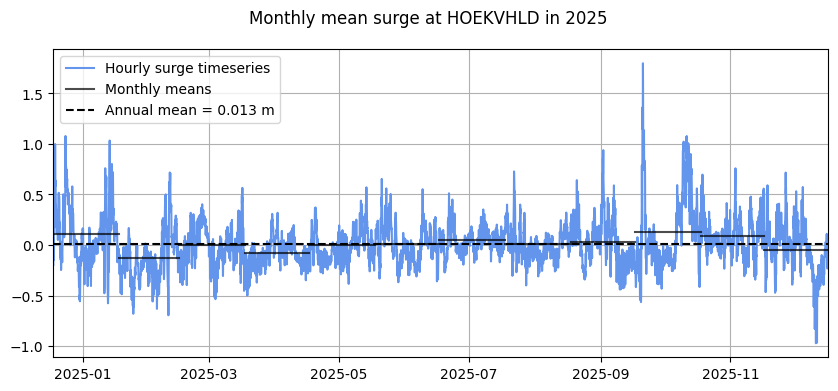

In [86]:
# Make a plot of timeseries and monthly means

fig,ax = plt.subplots(figsize=(10,4))
ax.plot(ds_year['time'],ds_year['surge'].sel(stations=station_ids[stname]), color='cornflowerblue', label='Hourly surge timeseries')

# add monthly mean lines
for mm in range(0,12):
    time1 = np.datetime64(f"{year}-{ds_all.sel(year=year)['month'][mm].values:02}")
    if mm==11:
        time2 = np.datetime64(f"{year}-{ds_all.sel(year=year)['month'][mm].values:02}-31")
    else:
        time2 = np.datetime64(f"{year}-{ds_all.sel(year=year)['month'][mm+1].values:02}")
    ax.plot([time1,time2],
    [ds_all['surge'].sel(stations=station_ids[stname], year=year).squeeze().values[mm],ds_all['surge'].sel(stations=station_ids[stname], year=year).squeeze().values[mm]],
    color='k', alpha=0.7, label='Monthly means' if mm==0 else "")

# add annual mean line
annual_mean = ds_all['surge'].sel(stations=station_ids[stname], year=year).mean().values.item()
ax.axhline(y=annual_mean, color='black', linestyle='--', label=f'Annual mean = {annual_mean:.3f} m')

ax.set_xlim([np.datetime64(f"{year}-01-01"), np.datetime64(f"{year}-12-31")])
ax.set_xticks([np.datetime64(f"{year}-{(m*2+1):02}-15") for m in range(0,6)])
ax.set_xticklabels([f"{year}-{(m*2+1):02}" for m in range(0,6)])
ax.grid()
ax.legend(loc='upper left')
fig.suptitle(f"Monthly mean surge at {ds_all['station_name'].sel(stations=station_ids[stname]).values.item()} in {year}")
fig.savefig(os.path.join(outdir_fig, f'monthly_means_surge_{ds_all.sel(stations=station_ids[stname]).station_name.values.item()}_2025_timeseries.png'), dpi=300)

### Plot of monthly means for all years

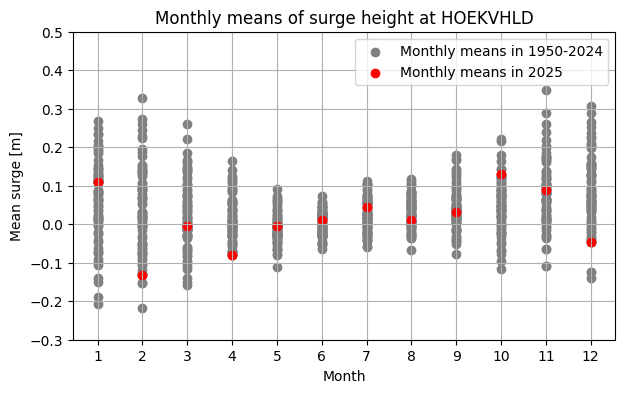

In [87]:
minmax=[-0.3, 0.5]
fig,ax = plt.subplots(figsize=(7,4))
yy=ds_all.year.values[0]
plt.scatter(ds_all.month.values,ds_all['surge'].sel(year=yy).sel(stations=station_id).values, c='gray', label = 'Monthly means in 1950-2024')
plt.scatter(ds_all.month.values,ds_all['surge'].sel(year=2025).sel(stations=station_id).values, c='red', label='Monthly means in 2025')
for yy in ds_all.year.values[1:]:
    plt.scatter(ds_all.month.values,ds_all['surge'].sel(year=yy).sel(stations=station_id).values, c='gray')
plt.scatter(ds_all.month.values,ds_all['surge'].sel(year=2025).sel(stations=station_id).values, c='red')
ax.legend()
ax.set_ylim(minmax)
ax.set_xlabel('Month')
ax.set_ylabel('Mean surge [m]')
ax.set_xticks(range(1,13))
ax.grid()
ax.set_title(f'Monthly means of surge height at {ds_all.sel(stations=station_id).station_name.values}')
fig.savefig(os.path.join(outdir_fig, f'monthly_means_surge_{ds_all.sel(stations=station_id).station_name.values.item()}.png'), dpi=300)

### Plot of yearly means for all stations

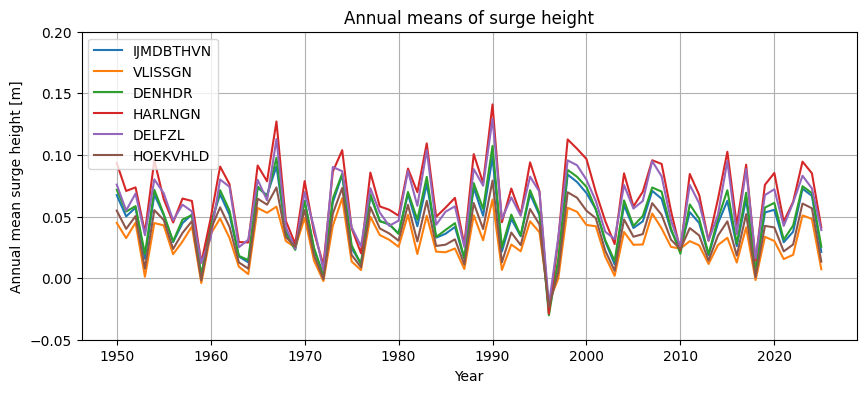

In [88]:
fig,ax = plt.subplots(figsize=(10,4))

for station_names, station_id in station_ids.items():
    ax.plot(ds_all['year'], ds_all['surge'].mean('month').sel(stations=station_id), 
    label=ds_all.sel(stations=station_id).station_name.values.item())

ax.legend()
ax.set_ylim([-0.05, 0.2])
ax.set_xlabel('Year')
ax.set_ylabel('Annual mean surge height [m]')
ax.grid()
ax.set_title(f'Annual means of surge height')
fig.savefig(os.path.join(outdir_fig, f'annual_means_surge_all_stations.png'), dpi=300)